# ResNet Face Similarity Model

Fine-tunes an ImageNet-pretrained ResNet as an ArcFace-style face embedding model on the
synthetic identity dataset (`dataset/raw/subjects_0-1999_72_imgs`, 2,000 subjects x 72 images).

Approach (standard closed-set face recognition training / open-set verification evaluation):

1. Split **by subject**: train subjects are used for identity classification (softmax + ArcFace margin).
2. Val/test subjects are held out entirely from training and are only used to build
   **verification pairs** (same-person vs different-person) to evaluate embedding quality via
   cosine similarity, ROC-AUC, and TAR@FAR — the standard face-verification protocol.

See `eda.ipynb` for background: faces are pre-aligned at 112x112 (no face detection needed),
the alpha channel is unused (drop it), and raw-pixel distances overlap heavily between same/different
identity pairs — motivating the learned-embedding approach here.

## 1. Setup

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print(f"Using device: {DEVICE}")

Using device: mps


In [2]:
# Resolve project root whether the notebook is launched from the repo root or from notebooks/
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "dataset").exists() else Path.cwd().parent
BASE = PROJECT_ROOT / "dataset" / "raw" / "subjects_0-1999_72_imgs"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
CHECKPOINT_DIR.mkdir(exist_ok=True)
RESNET_OUTPUTS = PROJECT_ROOT / "resnet_outputs"
RESNET_OUTPUTS.mkdir(exist_ok=True)

assert BASE.is_dir(), f"Dataset not found at {BASE} — see README for how to obtain it."
subject_ids = sorted(int(d.name) for d in BASE.iterdir() if d.is_dir() and not d.name.startswith("."))
print(f"Found {len(subject_ids)} subjects under {BASE}")

Found 2000 subjects under /Users/lita/Documents/Term 3/Advanced ML/final-project/facial-similarity-detection/dataset/raw/subjects_0-1999_72_imgs


In [3]:
# Training configuration. Lower IMAGES_PER_SUBJECT_TRAIN / NUM_EPOCHS for a quick smoke test.
CONFIG = {
    "backbone": "resnet50",          # "resnet18" (fast) or "resnet50" (heavier, better ceiling)
    "embedding_dim": 512,
    "arcface_scale": 30.0,
    "arcface_margin": 0.50,
    "image_size": 112,               # native resolution, matches the ArcFace/InsightFace convention
    "images_per_subject_train": 20,  # cap per-subject images during training for speed (max 72)
    "batch_size": 64,
    "num_epochs": 30,
    "lr": 3e-4,
    "weight_decay": 5e-4,
    "num_workers": 0,                # keep 0 in notebooks to avoid multiprocessing issues
    "num_verification_pairs": 3000,  # per class (positive / negative), drawn from val+test subjects
}
CONFIG

{'backbone': 'resnet50',
 'embedding_dim': 512,
 'arcface_scale': 30.0,
 'arcface_margin': 0.5,
 'image_size': 112,
 'images_per_subject_train': 20,
 'batch_size': 64,
 'num_epochs': 30,
 'lr': 0.0003,
 'weight_decay': 0.0005,
 'num_workers': 0,
 'num_verification_pairs': 3000}

## 2. Subject-level train/val/test split

Split by identity (never by image) so verification is evaluated on subjects the model never trained on.

In [4]:
rng = np.random.default_rng(SEED)
shuffled = subject_ids.copy()
rng.shuffle(shuffled)

n = len(shuffled)
n_train = int(n * 0.8)
n_val = int(n * 0.1)

train_subjects = sorted(shuffled[:n_train])
val_subjects = sorted(shuffled[n_train:n_train + n_val])
test_subjects = sorted(shuffled[n_train + n_val:])

print(f"Train subjects: {len(train_subjects)}")
print(f"Val subjects:   {len(val_subjects)}")
print(f"Test subjects:  {len(test_subjects)}")

subject_to_label = {sid: i for i, sid in enumerate(train_subjects)}
NUM_CLASSES = len(train_subjects)

Train subjects: 1600
Val subjects:   200
Test subjects:  200


## 3. Datasets

In [5]:
def list_subject_images(subject_id, limit=None):
    paths = sorted((BASE / str(subject_id)).glob("*.png"), key=lambda p: int(p.stem))
    if limit is not None:
        idx = np.linspace(0, len(paths) - 1, min(limit, len(paths)), dtype=int)
        paths = [paths[i] for i in idx]
    return paths


class FaceIdentityDataset(Dataset):
    """Returns (image, class_label) pairs for closed-set identity classification."""

    def __init__(self, subjects, subject_to_label, images_per_subject, transform):
        self.transform = transform
        self.samples = []
        for sid in subjects:
            label = subject_to_label[sid]
            for path in list_subject_images(sid, limit=images_per_subject):
                self.samples.append((path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")  # drop unused alpha channel
        return self.transform(img), label

In [6]:
from PIL import Image
from torchvision import transforms

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
SZ = CONFIG["image_size"]

train_transform = transforms.Compose([
    transforms.Resize((SZ, SZ)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((SZ, SZ)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds = FaceIdentityDataset(
    train_subjects, subject_to_label,
    images_per_subject=CONFIG["images_per_subject_train"],
    transform=train_transform,
)
train_loader = DataLoader(
    train_ds, batch_size=CONFIG["batch_size"], shuffle=True,
    num_workers=CONFIG["num_workers"], drop_last=True,
)
print(f"Train images: {len(train_ds)} across {NUM_CLASSES} identities")

Train images: 32000 across 1600 identities


## 4. Model: ResNet backbone + ArcFace head

In [7]:
class ArcMarginProduct(nn.Module):
    """ArcFace additive angular margin head (Deng et al., 2019)."""

    def __init__(self, in_features, out_features, scale=30.0, margin=0.50):
        super().__init__()
        self.scale = scale
        self.margin = margin
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)
        self.cos_m = np.cos(margin)
        self.sin_m = np.sin(margin)
        self.th = np.cos(np.pi - margin)
        self.mm = np.sin(np.pi - margin) * margin

    def forward(self, embeddings, labels):
        cosine = F.linear(F.normalize(embeddings), F.normalize(self.weight))
        sine = torch.sqrt((1.0 - cosine ** 2).clamp(min=1e-9))
        phi = cosine * self.cos_m - sine * self.sin_m
        phi = torch.where(cosine > self.th, phi, cosine - self.mm)

        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, labels.view(-1, 1), 1.0)
        logits = one_hot * phi + (1.0 - one_hot) * cosine
        return logits * self.scale

In [8]:
from torchvision import models

class ResNetFaceEmbedding(nn.Module):
    """ImageNet-pretrained ResNet backbone -> L2-normalized face embedding."""

    def __init__(self, backbone="resnet18", embedding_dim=512):
        super().__init__()
        if backbone == "resnet18":
            net = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
            feat_dim = net.fc.in_features
        elif backbone == "resnet50":
            net = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
            feat_dim = net.fc.in_features
        else:
            raise ValueError(f"Unknown backbone: {backbone}")

        net.fc = nn.Identity()
        self.backbone = net
        self.embedding = nn.Sequential(
            nn.Linear(feat_dim, embedding_dim),
            nn.BatchNorm1d(embedding_dim),
        )

    def forward(self, x):
        feats = self.backbone(x)
        emb = self.embedding(feats)
        return F.normalize(emb)


model = ResNetFaceEmbedding(CONFIG["backbone"], CONFIG["embedding_dim"]).to(DEVICE)
arc_head = ArcMarginProduct(
    CONFIG["embedding_dim"], NUM_CLASSES,
    scale=CONFIG["arcface_scale"], margin=CONFIG["arcface_margin"],
).to(DEVICE)

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(arc_head.parameters()),
    lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"],
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["num_epochs"])
criterion = nn.CrossEntropyLoss()

n_params = sum(p.numel() for p in model.parameters())
print(f"Backbone: {CONFIG['backbone']} | embedding dim: {CONFIG['embedding_dim']} | params: {n_params:,}")

Backbone: resnet50 | embedding dim: 512 | params: 24,558,144


## 5. Training loop

In [9]:
from tqdm.auto import tqdm

def train_one_epoch(epoch):
    model.train()
    arc_head.train()
    total_loss, correct, total = 0.0, 0, 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{CONFIG['num_epochs']}")
    for images, labels in pbar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        embeddings = model(images)
        logits = arc_head(embeddings, labels)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += images.size(0)
        pbar.set_postfix(loss=total_loss / total, acc=correct / total)

    scheduler.step()
    return total_loss / total, correct / total

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
history = {"loss": [], "acc": []}
best_acc = 0.0

for epoch in range(CONFIG["num_epochs"]):
    epoch_loss, epoch_acc = train_one_epoch(epoch)
    history["loss"].append(epoch_loss)
    history["acc"].append(epoch_acc)
    print(f"Epoch {epoch+1}: loss={epoch_loss:.4f} train_acc={epoch_acc:.4f}")

    if epoch_acc > best_acc:
        best_acc = epoch_acc
        torch.save(
            {"model": model.state_dict(), "config": CONFIG, "epoch": epoch},
            CHECKPOINT_DIR / "resnet_face_embedding_best.pt",
        )

print(f"Best train accuracy: {best_acc:.4f}")

Epoch 1/30: 100%|██████████| 500/500 [02:58<00:00,  2.80it/s, acc=3.13e-5, loss=19.3]


Epoch 1: loss=19.2744 train_acc=0.0000


Epoch 2/30: 100%|██████████| 500/500 [02:55<00:00,  2.85it/s, acc=0.025, loss=11.9]  


Epoch 2: loss=11.8963 train_acc=0.0250


Epoch 3/30: 100%|██████████| 500/500 [02:55<00:00,  2.85it/s, acc=0.313, loss=5.22]


...

Epoch 28: loss=0.0010 train_acc=0.9998


Epoch 29/30: 100%|██████████| 500/500 [03:03<00:00,  2.72it/s, acc=1, loss=0.000991]


Epoch 29: loss=0.0010 train_acc=0.9999


Epoch 30/30: 100%|██████████| 500/500 [03:01<00:00,  2.76it/s, acc=1, loss=0.000741]

Epoch 30: loss=0.0007 train_acc=1.0000
Best train accuracy: 1.0000


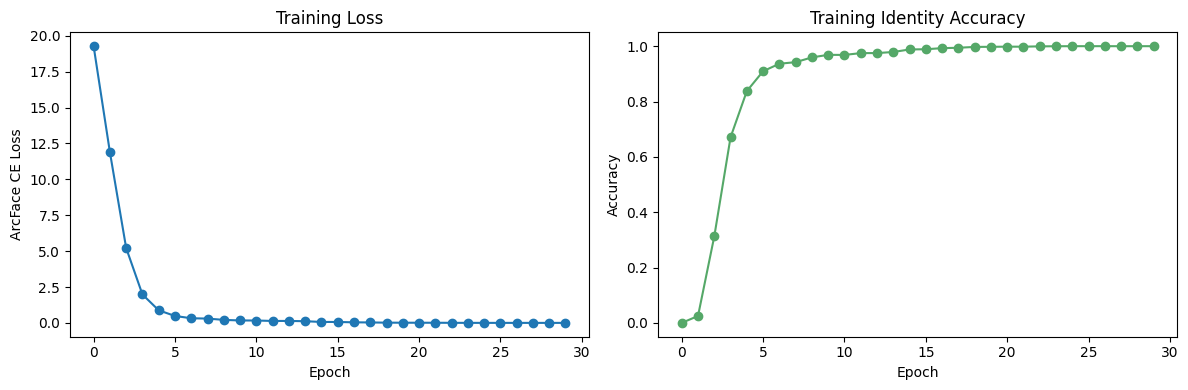

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["loss"], marker="o")
axes[0].set(title="Training Loss", xlabel="Epoch", ylabel="ArcFace CE Loss")
axes[1].plot(history["acc"], marker="o", color="#55A868")
axes[1].set(title="Training Identity Accuracy", xlabel="Epoch", ylabel="Accuracy")
plt.tight_layout()
plt.savefig(RESNET_OUTPUTS / "01_training_curves.png", bbox_inches="tight")
plt.show()

## 6. Verification evaluation on held-out subjects

Val/test subjects were never seen during training. We build same-identity (positive) and
different-identity (negative) pairs from them, embed both images, and score pairs by cosine
similarity — the standard face-verification protocol (as used by LFW/AgeDB-style benchmarks).

In [12]:
@torch.no_grad()
def embed_paths(paths, batch_size=128):
    model.eval()
    embeddings = []
    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i + batch_size]
        imgs = torch.stack([eval_transform(Image.open(p).convert("RGB")) for p in batch_paths])
        imgs = imgs.to(DEVICE)
        embeddings.append(model(imgs).cpu().numpy())
    return np.concatenate(embeddings, axis=0)

In [13]:
def build_verification_pairs(subjects, n_pairs, rng):
    """Sample n_pairs positive (same subject) and n_pairs negative (different subject) image pairs."""
    subject_images = {sid: list_subject_images(sid) for sid in subjects}

    pos_pairs = []
    while len(pos_pairs) < n_pairs:
        sid = rng.choice(subjects)
        imgs = subject_images[sid]
        if len(imgs) < 2:
            continue
        i, j = rng.choice(len(imgs), size=2, replace=False)
        pos_pairs.append((imgs[i], imgs[j]))

    neg_pairs = []
    while len(neg_pairs) < n_pairs:
        sid_a, sid_b = rng.choice(subjects, size=2, replace=False)
        img_a = subject_images[sid_a][rng.integers(len(subject_images[sid_a]))]
        img_b = subject_images[sid_b][rng.integers(len(subject_images[sid_b]))]
        neg_pairs.append((img_a, img_b))

    return pos_pairs, neg_pairs


eval_subjects = val_subjects + test_subjects
eval_rng = np.random.default_rng(SEED)
pos_pairs, neg_pairs = build_verification_pairs(
    eval_subjects, CONFIG["num_verification_pairs"], eval_rng
)
print(f"Built {len(pos_pairs)} positive and {len(neg_pairs)} negative verification pairs")

Built 3000 positive and 3000 negative verification pairs


In [14]:
def pairs_to_similarities(pairs):
    left_paths = [p[0] for p in pairs]
    right_paths = [p[1] for p in pairs]
    left_emb = embed_paths(left_paths)
    right_emb = embed_paths(right_paths)
    return np.sum(left_emb * right_emb, axis=1)  # embeddings are L2-normalized -> dot = cosine sim


pos_sims = pairs_to_similarities(pos_pairs)
neg_sims = pairs_to_similarities(neg_pairs)
print(f"Positive pair similarity: mean={pos_sims.mean():.4f} std={pos_sims.std():.4f}")
print(f"Negative pair similarity: mean={neg_sims.mean():.4f} std={neg_sims.std():.4f}")

Positive pair similarity: mean=0.4757 std=0.2289
Negative pair similarity: mean=0.0072 std=0.0716


In [15]:
from sklearn.metrics import roc_curve, auc

y_true = np.concatenate([np.ones_like(pos_sims), np.zeros_like(neg_sims)])
y_score = np.concatenate([pos_sims, neg_sims])

fpr, tpr, thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

# Best threshold via Youden's J statistic
best_idx = np.argmax(tpr - fpr)
best_threshold = thresholds[best_idx]
best_acc_verif = np.mean((y_score >= best_threshold) == y_true.astype(bool))

def tar_at_far(target_far):
    idx = np.searchsorted(fpr, target_far, side="right") - 1
    idx = max(idx, 0)
    return tpr[idx]

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Best threshold: {best_threshold:.4f} -> verification accuracy: {best_acc_verif:.4f}")
print(f"TAR@FAR=1e-2: {tar_at_far(0.01):.4f}")
print(f"TAR@FAR=1e-3: {tar_at_far(0.001):.4f}")

ROC-AUC: 0.9717
Best threshold: 0.1475 -> verification accuracy: 0.9252
TAR@FAR=1e-2: 0.8227
TAR@FAR=1e-3: 0.6950


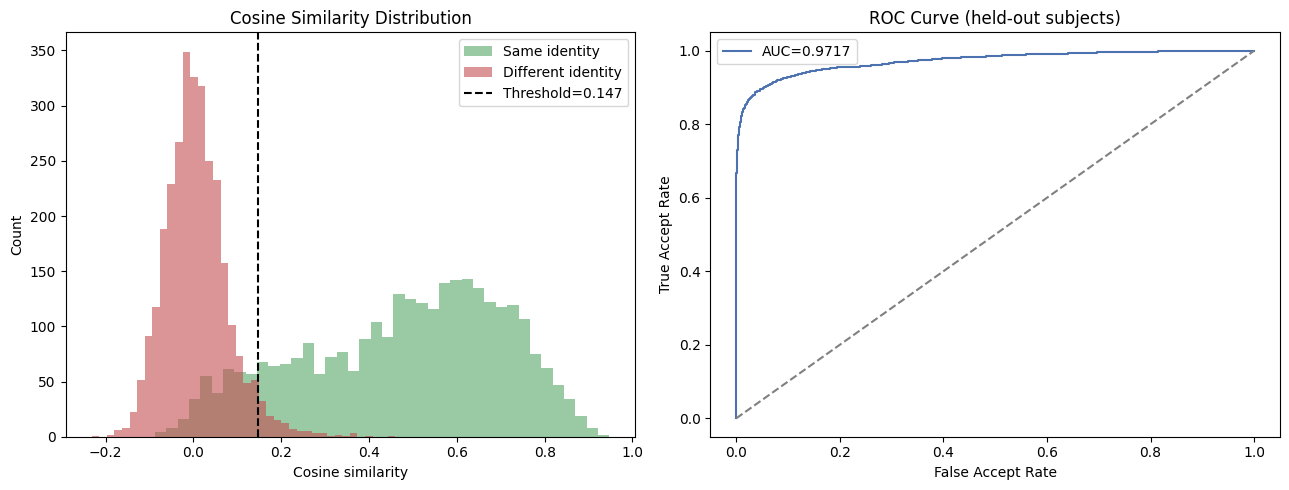

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(pos_sims, bins=40, alpha=0.6, label="Same identity", color="#55A868")
axes[0].hist(neg_sims, bins=40, alpha=0.6, label="Different identity", color="#C44E52")
axes[0].axvline(best_threshold, color="black", ls="--", label=f"Threshold={best_threshold:.3f}")
axes[0].set(title="Cosine Similarity Distribution", xlabel="Cosine similarity", ylabel="Count")
axes[0].legend()

axes[1].plot(fpr, tpr, color="#4C72B0", label=f"AUC={roc_auc:.4f}")
axes[1].plot([0, 1], [0, 1], color="gray", ls="--")
axes[1].set(title="ROC Curve (held-out subjects)", xlabel="False Accept Rate", ylabel="True Accept Rate")
axes[1].legend()

plt.tight_layout()
plt.savefig(RESNET_OUTPUTS / "02_verification_distributions_roc.png", bbox_inches="tight")
plt.show()

### FAR / FRR / EER report

Alternative reporting style to the ROC-AUC/TAR@FAR metrics above: computes **all** pairwise
similarities among the held-out images (not just a balanced 1:1 sample of positive/negative
pairs), subsamples down to a manageable pair count if needed, and reports False Accept Rate (FAR)
and False Reject Rate (FRR) across a threshold sweep plus the Equal Error Rate (EER) — the
threshold where FAR and FRR cross, a standard single-number biometric summary.

In [17]:
def far_frr_eer_report(subjects, images_per_subject=10, max_pairs=500_000,
                       thresholds=(0.20, 0.30, 0.40, 0.50, 0.60, 0.70), seed=SEED):
    """Exhaustive-pairs FAR/FRR/EER evaluation over the given held-out subjects."""
    rng = np.random.default_rng(seed)

    paths, labels = [], []
    for sid in subjects:
        for p in list_subject_images(sid, limit=images_per_subject):
            paths.append(p)
            labels.append(sid)
    labels = np.array(labels)

    embeddings = embed_paths(paths)  # (N, d), L2-normalized -> dot product = cosine similarity
    sim_matrix = embeddings @ embeddings.T
    iu = np.triu_indices(len(paths), k=1)
    sims_all = sim_matrix[iu]
    same_all = labels[iu[0]] == labels[iu[1]]
    total_pairs = len(sims_all)

    print("[Eval] Computing FAR/FRR...")
    if total_pairs > max_pairs:
        sel = rng.choice(total_pairs, size=max_pairs, replace=False)
        sims, same = sims_all[sel], same_all[sel]
        print(f"[Eval] Subsampled {max_pairs} pairs from {total_pairs}")
    else:
        sims, same = sims_all, same_all

    genuine = sims[same]
    impostor = sims[~same]
    print(f"[Eval] Pairs — genuine: {len(genuine)}, impostor: {len(impostor)}")

    fine_thresholds = np.linspace(sims.min(), sims.max(), 2000)
    far_fine = np.array([(impostor >= t).mean() for t in fine_thresholds])
    frr_fine = np.array([(genuine < t).mean() for t in fine_thresholds])
    eer_idx = np.argmin(np.abs(far_fine - frr_fine))
    eer = (far_fine[eer_idx] + frr_fine[eer_idx]) / 2
    eer_threshold = fine_thresholds[eer_idx]

    print()
    print("=" * 60)
    print("EVALUATION RESULTS (FAR / FRR)")
    print("=" * 60)
    print(f"  Genuine pairs:  {len(genuine)}")
    print(f"  Impostor pairs: {len(impostor)}")
    print(f"  EER:            {eer:.4f} @ threshold={eer_threshold:.4f}")
    print()
    print(f"  {'Threshold':<10} {'FAR':<10} {'FRR':<10}")
    print(f"  {'-'*9}  {'-'*7}  {'-'*7}")
    for t in thresholds:
        far = (impostor >= t).mean()
        frr = (genuine < t).mean()
        print(f"  {t:<10.2f} {far:<10.4f} {frr:<10.4f}")
    print("=" * 60)

    return {"eer": eer, "eer_threshold": eer_threshold, "genuine": genuine, "impostor": impostor}

In [18]:
# Pooled val+test subjects (same pool as Section 6's ROC-AUC evaluation above)
pooled_far_frr = far_frr_eer_report(eval_subjects)

[Eval] Computing FAR/FRR...
[Eval] Subsampled 500000 pairs from 7998000
[Eval] Pairs — genuine: 1091, impostor: 498909

EVALUATION RESULTS (FAR / FRR)
  Genuine pairs:  1091
  Impostor pairs: 498909
  EER:            0.0802 @ threshold=0.1012

  Threshold  FAR        FRR       
  ---------  -------  -------
  0.20       0.0123     0.1742    
  0.30       0.0025     0.2566    
  0.40       0.0006     0.3593    
  0.50       0.0001     0.4858    
  0.60       0.0000     0.6654    
  0.70       0.0000     0.8478    


## 7. Embedding space visualization

Compare against `eda_outputs/08_embeddings.png` (raw-pixel PCA/t-SNE) — the learned embeddings
below should separate identities far more cleanly than raw pixels did.

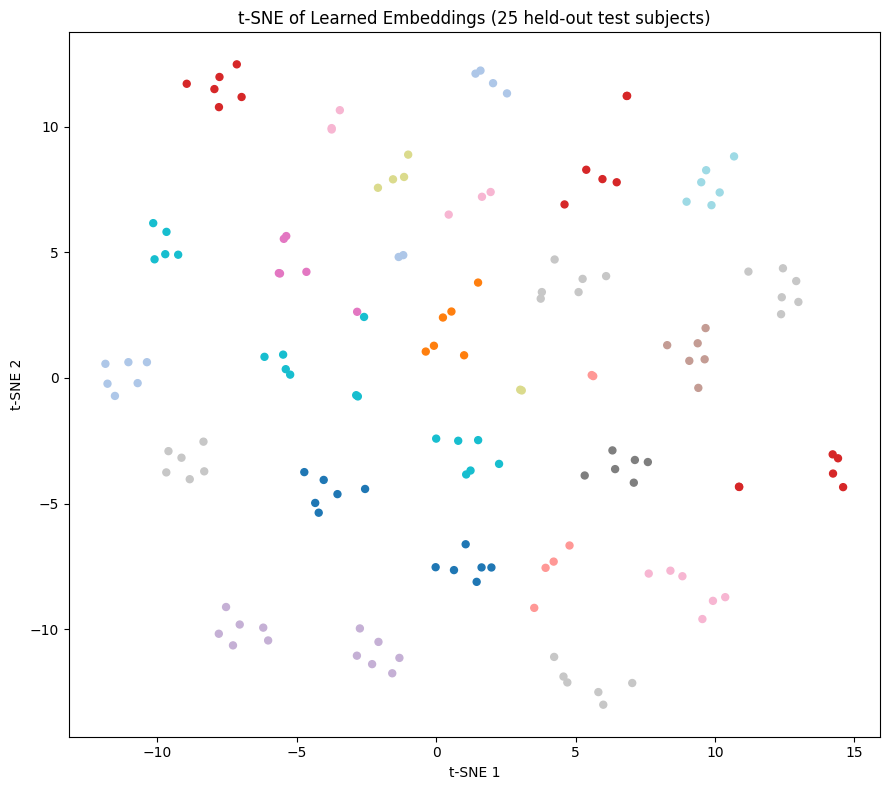

In [19]:
from sklearn.manifold import TSNE

n_vis_subjects = 25
vis_subjects = list(np.random.default_rng(SEED).choice(test_subjects, size=n_vis_subjects, replace=False))

vis_paths, vis_labels = [], []
for sid in vis_subjects:
    for p in list_subject_images(sid, limit=6):
        vis_paths.append(p)
        vis_labels.append(sid)

vis_embeddings = embed_paths(vis_paths)
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED)
proj = tsne.fit_transform(vis_embeddings)

plt.figure(figsize=(9, 8))
scatter = plt.scatter(proj[:, 0], proj[:, 1], c=vis_labels, cmap="tab20", s=25)
plt.title(f"t-SNE of Learned Embeddings ({n_vis_subjects} held-out test subjects)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.savefig(RESNET_OUTPUTS / "03_tsne_embeddings.png", bbox_inches="tight")
plt.show()

## 8. Final evaluation: test split only

Section 6 pooled val + test subjects into one verification set. Val subjects were never actually
used to tune anything in this notebook, but proper methodology reports one clean, final number
using **only the test split** — held out from both training and any earlier inspection.

In [20]:
test_rng = np.random.default_rng(SEED)
test_pos_pairs, test_neg_pairs = build_verification_pairs(
    test_subjects, CONFIG["num_verification_pairs"], test_rng
)
print(f"Built {len(test_pos_pairs)} positive and {len(test_neg_pairs)} negative test-only pairs")

test_pos_sims = pairs_to_similarities(test_pos_pairs)
test_neg_sims = pairs_to_similarities(test_neg_pairs)
print(f"Positive pair similarity: mean={test_pos_sims.mean():.4f} std={test_pos_sims.std():.4f}")
print(f"Negative pair similarity: mean={test_neg_sims.mean():.4f} std={test_neg_sims.std():.4f}")

test_y_true = np.concatenate([np.ones_like(test_pos_sims), np.zeros_like(test_neg_sims)])
test_y_score = np.concatenate([test_pos_sims, test_neg_sims])

test_fpr, test_tpr, test_thresholds = roc_curve(test_y_true, test_y_score)
test_roc_auc = auc(test_fpr, test_tpr)

test_best_idx = np.argmax(test_tpr - test_fpr)
test_best_threshold = test_thresholds[test_best_idx]
test_best_acc = np.mean((test_y_score >= test_best_threshold) == test_y_true.astype(bool))

def tar_at_far_on(fpr, tpr, target_far):
    idx = max(np.searchsorted(fpr, target_far, side="right") - 1, 0)
    return tpr[idx]

print(f"Test-only ROC-AUC: {test_roc_auc:.4f}")
print(f"Test-only best threshold: {test_best_threshold:.4f} -> accuracy: {test_best_acc:.4f}")
print(f"Test-only TAR@FAR=1e-2: {tar_at_far_on(test_fpr, test_tpr, 0.01):.4f}")
print(f"Test-only TAR@FAR=1e-3: {tar_at_far_on(test_fpr, test_tpr, 0.001):.4f}")

Built 3000 positive and 3000 negative test-only pairs
Positive pair similarity: mean=0.4810 std=0.2277
Negative pair similarity: mean=0.0039 std=0.0681
Test-only ROC-AUC: 0.9751
Test-only best threshold: 0.1282 -> accuracy: 0.9355
Test-only TAR@FAR=1e-2: 0.8563
Test-only TAR@FAR=1e-3: 0.7083


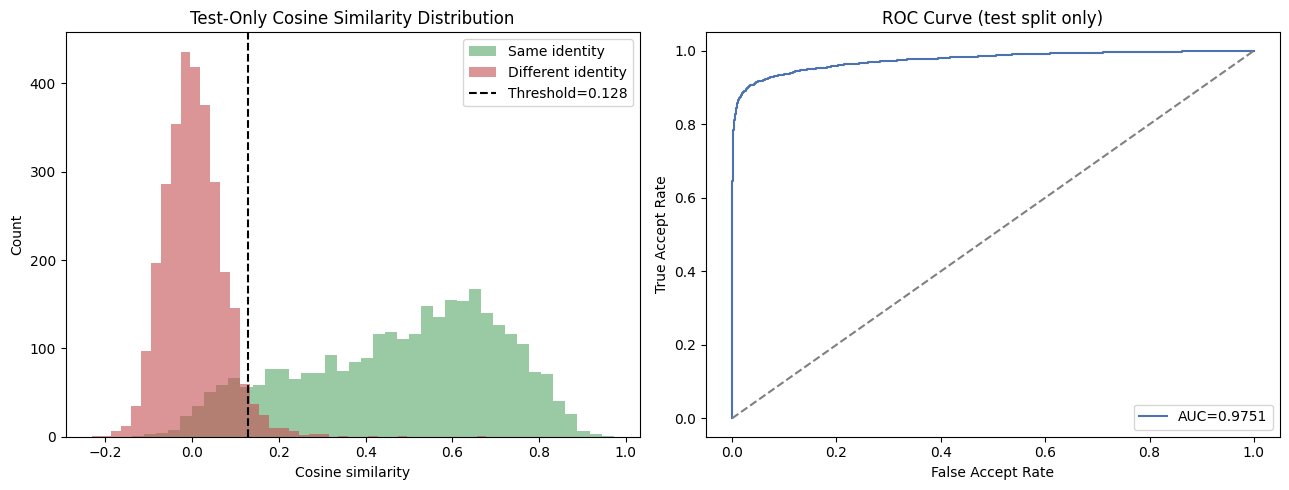

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(test_pos_sims, bins=40, alpha=0.6, label="Same identity", color="#55A868")
axes[0].hist(test_neg_sims, bins=40, alpha=0.6, label="Different identity", color="#C44E52")
axes[0].axvline(test_best_threshold, color="black", ls="--", label=f"Threshold={test_best_threshold:.3f}")
axes[0].set(title="Test-Only Cosine Similarity Distribution", xlabel="Cosine similarity", ylabel="Count")
axes[0].legend()

axes[1].plot(test_fpr, test_tpr, color="#4C72B0", label=f"AUC={test_roc_auc:.4f}")
axes[1].plot([0, 1], [0, 1], color="gray", ls="--")
axes[1].set(title="ROC Curve (test split only)", xlabel="False Accept Rate", ylabel="True Accept Rate")
axes[1].legend()

plt.tight_layout()
plt.savefig(RESNET_OUTPUTS / "04_test_only_distributions_roc.png", bbox_inches="tight")
plt.show()

In [22]:
# Test-split only (same pool as Section 8's ROC-AUC evaluation above)
test_far_frr = far_frr_eer_report(test_subjects)

[Eval] Computing FAR/FRR...
[Eval] Subsampled 500000 pairs from 1999000
[Eval] Pairs — genuine: 2234, impostor: 497766

EVALUATION RESULTS (FAR / FRR)
  Genuine pairs:  2234
  Impostor pairs: 497766
  EER:            0.0716 @ threshold=0.1068

  Threshold  FAR        FRR       
  ---------  -------  -------
  0.20       0.0128     0.1504    
  0.30       0.0029     0.2529    
  0.40       0.0007     0.3483    
  0.50       0.0002     0.4803    
  0.60       0.0000     0.6432    
  0.70       0.0000     0.8290    


In [28]:
# save model
torch.save(model.state_dict(), "/Users/lita/Documents/Term 3/Advanced ML/final-project/facial-similarity-detection/resnet_outputs/resnet_model.pth")


## 9. Test the model on face images

Loads the saved checkpoint directly from disk (independent of whatever is currently in memory),
so you can test face pairs without re-running training. Works with any two image paths — swap in
your own photos to try it beyond this dataset.

In [23]:
def load_face_model(checkpoint_path):
    ckpt = torch.load(checkpoint_path, map_location=DEVICE)
    cfg = ckpt["config"]
    m = ResNetFaceEmbedding(cfg["backbone"], cfg["embedding_dim"]).to(DEVICE)
    m.load_state_dict(ckpt["model"])
    m.eval()
    return m, cfg, ckpt["epoch"]


test_model, test_cfg, test_epoch = load_face_model(CHECKPOINT_DIR / "resnet_face_embedding_best.pt")
print(f"Loaded checkpoint: backbone={test_cfg['backbone']} | embedding_dim={test_cfg['embedding_dim']} | saved at epoch {test_epoch + 1}")

test_face_transform = transforms.Compose([
    transforms.Resize((test_cfg["image_size"], test_cfg["image_size"])),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


@torch.no_grad()
def compare_faces(path_a, path_b, threshold=best_threshold):
    """Returns (cosine_similarity, verdict_str) for two face image paths."""
    img_a = test_face_transform(Image.open(path_a).convert("RGB")).unsqueeze(0).to(DEVICE)
    img_b = test_face_transform(Image.open(path_b).convert("RGB")).unsqueeze(0).to(DEVICE)
    emb_a = test_model(img_a)
    emb_b = test_model(img_b)
    similarity = F.cosine_similarity(emb_a, emb_b).item()
    verdict = "SAME person" if similarity >= threshold else "DIFFERENT people"
    return similarity, verdict

Loaded checkpoint: backbone=resnet50 | embedding_dim=512 | saved at epoch 27


Same-subject test (subject 5): similarity=0.4241 -> SAME person


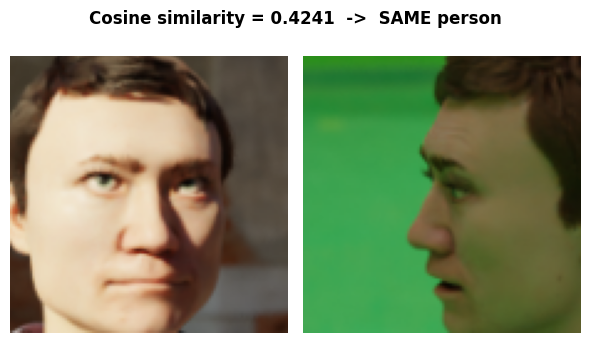

Different-subject test (subjects 5 vs 32): similarity=0.0126 -> DIFFERENT people


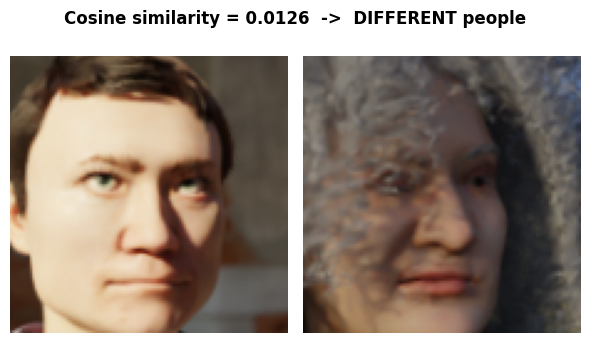

In [35]:
def show_face_pair(path_a, path_b, similarity, verdict):
    fig, axes = plt.subplots(1, 2, figsize=(6, 3.5))
    axes[0].imshow(Image.open(path_a).convert("RGB")); axes[0].axis("off")
    axes[1].imshow(Image.open(path_b).convert("RGB")); axes[1].axis("off")
    fig.suptitle(f"Cosine similarity = {similarity:.4f}  ->  {verdict}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(RESNET_OUTPUTS / "05_face_test_demo.png", bbox_inches="tight")
    plt.show()


# Example 1: two images of the SAME held-out test subject
demo_sid = test_subjects[0]
img_a, img_b = list_subject_images(demo_sid, limit=2)
sim, verdict = compare_faces(img_a, img_b)
print(f"Same-subject test (subject {demo_sid}): similarity={sim:.4f} -> {verdict}")
show_face_pair(img_a, img_b, sim, verdict)

# Example 2: two DIFFERENT held-out test subjects
sid_a, sid_b = test_subjects[0], test_subjects[1]
img_a2 = list_subject_images(sid_a, limit=1)[0]
img_b2 = list_subject_images(sid_b, limit=1)[0]
sim2, verdict2 = compare_faces(img_a2, img_b2)
print(f"Different-subject test (subjects {sid_a} vs {sid_b}): similarity={sim2:.4f} -> {verdict2}")
show_face_pair(img_a2, img_b2, sim2, verdict2)



0.27511435747146606 SAME person


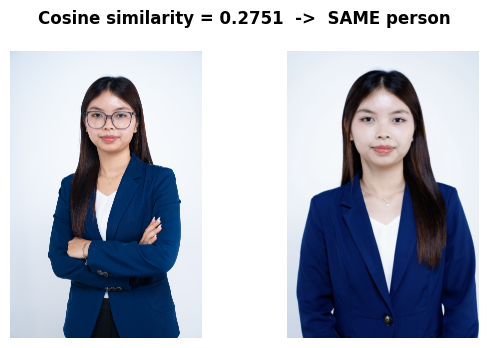

In [38]:
# Try your own images: with resnet_model.pth
sim, verdict = compare_faces(
    "/Users/lita/Documents/Term 3/Advanced ML/final-project/facial-similarity-detection/dataset/real/Pun-Solita.jpg",
    "/Users/lita/Documents/Term 3/Advanced ML/final-project/facial-similarity-detection/dataset/real/IMG_3215 Large.jpeg"
)
print(sim, verdict)
show_face_pair(
    "/Users/lita/Documents/Term 3/Advanced ML/final-project/facial-similarity-detection/dataset/real/Pun-Solita.jpg",
    "/Users/lita/Documents/Term 3/Advanced ML/final-project/facial-similarity-detection/dataset/real/IMG_3215 Large.jpeg",
    sim, verdict
)


## Next steps

- Swap `CONFIG["backbone"]` to `"resnet50"` and increase `images_per_subject_train` / `num_epochs`
  for a stronger model once the pipeline is validated end-to-end.
- Extend `dataset/raw/casia_webface` (needs `scripts/extract_recordio.py`) as a second, real-face
  training source per the project's goal of generalizing beyond synthetic faces.
- Benchmark pretrained ArcFace/CosFace/AdaFace checkpoints against the same verification pairs
  here for a head-to-head comparison (project goal 2), and against the standard eval sets in
  `dataset/raw/archive/eval/*.bin` (LFW, AgeDB-30, CFP-FP, etc.).